# Introduction to Deep Learning, Assignment 2, Task 2


# Function definitions for creating the datasets

First we need to create our datasets that are going to be used for training our models.

In order to create image queries of simple arithmetic operations such as '15+13' or '42-10' we need to create images of '+' and '-' signs using ***open-cv*** library. We will use these operand signs together with the MNIST dataset to represent the digits.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import numpy as np
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Dense, RNN, LSTM, Flatten, TimeDistributed, LSTMCell
from tensorflow.keras.layers import RepeatVector, Conv2D, SimpleRNN, GRU, Reshape, ConvLSTM2D, Conv2DTranspose

2025-12-08 13:31:15.744895: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-08 13:31:26.791722: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-08 13:32:13.124835: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


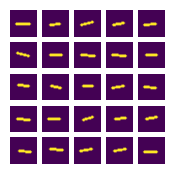

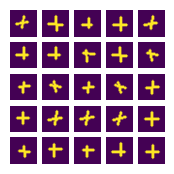

In [2]:
from scipy.ndimage import rotate


# Create plus/minus operand signs
def generate_images(number_of_images=50, sign='-'):
    blank_images = np.zeros([number_of_images, 28, 28])  # Dimensionality matches the size of MNIST images (28x28)
    x = np.random.randint(12, 16, (number_of_images, 2)) # Randomized x coordinates
    y1 = np.random.randint(6, 10, number_of_images)       # Randomized y coordinates
    y2 = np.random.randint(18, 22, number_of_images)     # -||-

    for i in range(number_of_images): # Generate n different images
        cv2.line(blank_images[i], (y1[i], x[i,0]), (y2[i], x[i, 1]), (255,0,0), 2, cv2.LINE_AA)     # Draw lines with randomized coordinates
        if sign == '+':
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA) # Draw lines with randomized coordinates

    return blank_images

def show_generated(images, n=5):
    plt.figure(figsize=(2, 2))
    for i in range(n**2):
        plt.subplot(n, n, i+1)
        plt.axis('off')
        plt.imshow(images[i])
    plt.show()

show_generated(generate_images())
show_generated(generate_images(sign='+'))

In [3]:
def create_data(highest_integer, num_addends=2, operands=['+', '-']):
    """
    Creates the following data for all pairs of integers up to [1:highest integer][+/-][1:highest_integer]:

    @return:
    X_text: '51+21' -> text query of an arithmetic operation (5)
    X_img : Stack of MNIST images corresponding to the query (5 x 28 x 28) -> sequence of 5 images of size 28x28
    y_text: '72' -> answer of the arithmetic text query
    y_img :  Stack of MNIST images corresponding to the answer (3 x 28 x 28)

    Images for digits are picked randomly from the whole MNIST dataset.
    """

    num_indices = [np.where(MNIST_labels==x) for x in range(10)]
    num_data = [MNIST_data[inds] for inds in num_indices]
    image_mapping = dict(zip(unique_characters[:10], num_data))
    image_mapping['-'] = generate_images()
    image_mapping['+'] = generate_images(sign='+')
    image_mapping['*'] = generate_images(sign='*')
    image_mapping[' '] = np.zeros([1, 28, 28])

    X_text, X_img, y_text, y_img = [], [], [], []

    for i in range(highest_integer + 1):      # First addend
        for j in range(highest_integer + 1):  # Second addend
            for sign in operands: # Create all possible combinations of operands
                query_string = to_padded_chars(str(i) + sign + str(j), max_len=max_query_length, pad_right=True)
                query_image = []
                for n, char in enumerate(query_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    query_image.append(image_set[index].squeeze())

                result = eval(query_string)
                result_string = to_padded_chars(result, max_len=max_answer_length, pad_right=True)
                result_image = []
                for n, char in enumerate(result_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    result_image.append(image_set[index].squeeze())

                X_text.append(query_string)
                X_img.append(np.stack(query_image))
                y_text.append(result_string)
                y_img.append(np.stack(result_image))

    return np.stack(X_text), np.stack(X_img)/255., np.stack(y_text), np.stack(y_img)/255.

def to_padded_chars(integer, max_len=3, pad_right=False):
    """
    Returns a string of len()=max_len, containing the integer padded with ' ' on either right or left side
    """
    length = len(str(integer))
    padding = (max_len - length) * ' '
    if pad_right:
        return str(integer) + padding
    else:
        return padding + str(integer)


# Creating our data

The dataset consists of 20000 samples that (additions and subtractions between all 2-digit integers) and they have two kinds of inputs and label modalities:

  **X_text**: strings containing queries of length 5: ['  1+1  ', '11-18', ...]

  **X_image**: a stack of images representing a single query, dimensions: [5, 28, 28]

  **y_text**: strings containing answers of length 3: ['  2', '156']

  **y_image**: a stack of images that represents the answer to a query, dimensions: [3, 28, 28]

(20000,) (20000, 5, 28, 28) (20000,) (20000, 3, 28, 28)
Query #9893

X_text: "49-46" = y_text: "3  "


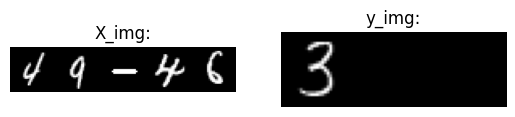

Query #7312

X_text: "36+56" = y_text: "92 "


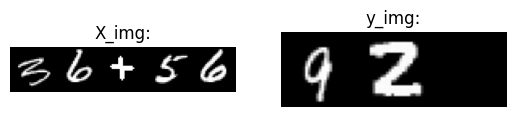

Query #1738

X_text: "8+69 " = y_text: "77 "


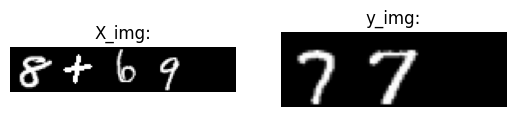

Query #214

X_text: "1+7  " = y_text: "8  "


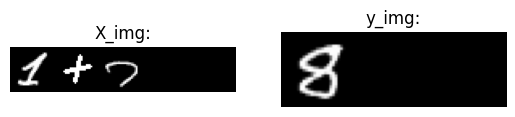

Query #5889

X_text: "29-44" = y_text: "-15"


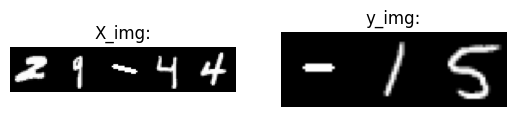

Query #6903

X_text: "34-51" = y_text: "-17"


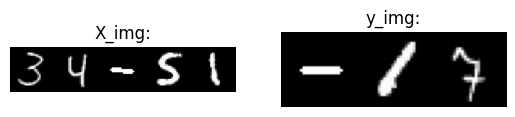

Query #3184

X_text: "15+92" = y_text: "107"


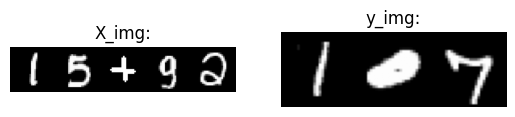

Query #1603

X_text: "8-1  " = y_text: "7  "


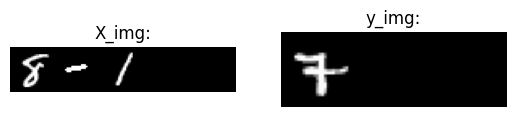

Query #9582

X_text: "47+91" = y_text: "138"


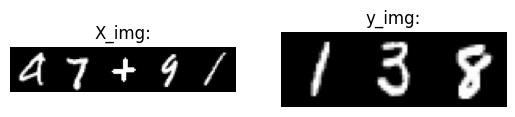

Query #9982

X_text: "49+91" = y_text: "140"


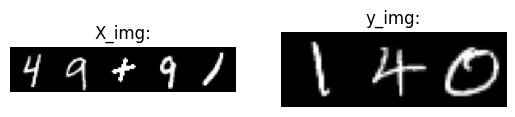

In [4]:
# Illustrate the generated query/answer pairs

unique_characters = '0123456789+- '       # All unique characters that are used in the queries (13 in total: digits 0-9, 2 operands [+, -], and a space character ' '.)
highest_integer = 99                      # Highest value of integers contained in the queries

max_int_length = len(str(highest_integer))# Maximum number of characters in an integer
max_query_length = max_int_length * 2 + 1 # Maximum length of the query string (consists of two integers and an operand [e.g. '22+10'])
max_answer_length = 3    # Maximum length of the answer string (the longest resulting query string is ' 1-99'='-98')

# Create the data (might take around a minute)
(MNIST_data, MNIST_labels), _ = tf.keras.datasets.mnist.load_data()
X_text, X_img, y_text, y_img = create_data(highest_integer)
print(X_text.shape, X_img.shape, y_text.shape, y_img.shape)


## Display the samples that were created
def display_sample(n):
    labels = ['X_img:', 'y_img:']
    for i, data in enumerate([X_img, y_img]):
        plt.subplot(1,2,i+1)
        # plt.set_figheight(15)
        plt.axis('off')
        plt.title(labels[i])
        plt.imshow(np.hstack(data[n]), cmap='gray')
    print('='*50, f'\nQuery #{n}\n\nX_text: "{X_text[n]}" = y_text: "{y_text[n]}"')
    plt.show()

for _ in range(10):
    display_sample(np.random.randint(0, 10000, 1)[0])

## Helper functions

The functions below will help with input/output of the data.

In [5]:
# One-hot encoding/decoding the text queries/answers so that they can be processed using RNNs
# You should use these functions to convert your strings and read out the output of your networks

def encode_labels(labels, max_len=3):
  n = len(labels)
  length = len(labels[0])
  char_map = dict(zip(unique_characters, range(len(unique_characters))))
  one_hot = np.zeros([n, length, len(unique_characters)])
  for i, label in enumerate(labels):
      m = np.zeros([length, len(unique_characters)])
      for j, char in enumerate(label):
          m[j, char_map[char]] = 1
      one_hot[i] = m

  return one_hot


def decode_labels(labels):
    pred = np.argmax(labels, axis=2)
    predicted = [''.join([unique_characters[i] for i in j]) for j in pred]

    return predicted

X_text_onehot = encode_labels(X_text)
y_text_onehot = encode_labels(y_text)

print(X_text_onehot.shape, y_text_onehot.shape)

(20000, 5, 13) (20000, 3, 13)



---
---

## II. Image to text RNN Model

Hint: There are two ways of building the encoder for such a model - again by using the regular LSTM cells (with flattened images as input vectors) or recurrect convolutional layers [ConvLSTM2D](https://keras.io/api/layers/recurrent_layers/conv_lstm2d/).

The goal here is to use **X_img** as inputs and **y_text** as outputs.

# My own helper functions

In the models below teacher forcing is used. For this the vocabulary will need a start and end token. Subsequently the one-hot encoding and decoding functions need to be altered to include these.

In [6]:
# Teacher forcing preparation
vocabulary_tf = list(unique_characters)+['<start>','<end>'] 

indices = {char:i for i, char in enumerate(vocabulary_tf)}
reverse_indices={i:char for i,char in enumerate(vocabulary_tf)}


# One-hot encoding
def encode_labels_tf(labels, vocabulary=vocabulary_tf, indices_map=indices):
  n = len(labels)
  length = len(labels[0])+2 # for start of sequence <start> and end of sequence <end> tokens.

  one_hot = np.zeros([n, length, len(vocabulary)])
  for i, label in enumerate(labels):
    full_label = ['<start>'] + list(label) + ['<end>']
    m = np.zeros([length, len(vocabulary)])
    for j, char in enumerate(full_label):
       m[j, indices_map[char]] = 1
    one_hot[i] = m

  return one_hot

# One-hot decoding
def decode_labels_tf(labels, vocabulary=vocabulary_tf, indices_map = reverse_indices):
    pred = np.argmax(labels, axis=2)
    predicted = [''.join([indices_map[i] for i in j]) for j in pred]

    return predicted

X_text_onehot = encode_labels_tf(X_text)
y_text_onehot = encode_labels_tf(y_text)

print(X_text_onehot.shape, y_text_onehot.shape)

(20000, 7, 15) (20000, 5, 15)


# Lame ass-boring models

### Model 2

The model below uses an ConvLTSM2D layer for the encoder, a dense layer for the bridge, and an LSTM layer for the decoder. It also uses teacher forcing to better predict sequences. For this the output sequence needs to become longer, and the vocabulary needs to be adapted to also inlude a start-of-sequence $<start>$ and an end-of-sequence $<end>$ token. The decoder will use both the sequence of tensors produced by the ConvLSTM2D layer and the $y_\text{text onehot}[\text{from start to last digit}]$ vector as an inputdata, while using the $y_\text{text onehot}[\text{from first digit to end}]$ as the train data. The one-hot encoder will need to be of higher dimension, so I create my own encode_labels and decode_labels funcions.

In [9]:
# Your code is: damn code

from tensorflow.keras.layers import BatchNormalization, Activation, MaxPooling2D, LSTM, TimeDistributed, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import L2


# First we create a build-encoder function
def build_image2text_encoder(dropout, RLstrength, max_size=512):
    
    # Initialize an encoder
    encoder = tf.keras.Sequential()

    # Build encoder layers
    ## Block 1
    encoder.add(TimeDistributed(
            Conv2D(32, (3,3), padding = "same"),
            input_shape = (5,28,28,1))) # 5 times a grayscale image
    encoder.add(TimeDistributed(BatchNormalization(), name='BN1'))
    encoder.add(TimeDistributed(Activation('relu'), name='acti1'))
    encoder.add(TimeDistributed(Dropout(dropout), name='DO1'))
    encoder.add(TimeDistributed(MaxPooling2D(), name='MP2D_1'))
    
    ## Block 2
    encoder.add(TimeDistributed(
            Conv2D(64, (3,3), padding = "same")))
    encoder.add(TimeDistributed(BatchNormalization()))
    encoder.add(TimeDistributed(Activation('relu')))
    encoder.add(TimeDistributed(Dropout(dropout)))
    encoder.add(TimeDistributed(MaxPooling2D()))

    ## Recurrent convolutional layers
    encoder.add(
        ConvLSTM2D(
            filters=128, 
            kernel_size=(3,3), 
            padding='same',
            return_sequences=False, 
            use_bias=True, 
            return_state=True, 
            name='ConvLSTM', 
            dropout=dropout, 
            recurrent_dropout=dropout,
            recurrent_regularizer = L2(RLstrength))
    )

    return encoder


# Secondly we create a build-decoder function
def build_image2text_decoder(dropout, max_size=512): 

    lstm = LSTM(max_size, return_sequences = True, dropout = dropout, recurrent_dropout = dropout)
    dense = TimeDistributed(Dense(len(teacher_forcing_vocab), activation='softmax'))

    return lstm, dense


# Here we build the full model
def build_image2text(dropout = 0.3, max_size=512, learning_rate = 2.5e-4, max_answer_length_tf=4,RLstrength=1.0e-4):


    # Define input layer of full model
    X_in = Input(shape = (5,28,28,1), name = 'sequence')
    Y_in = Input(shape=(max_answer_length_tf, len(teacher_forcing_vocab)))


    # Encoder step
    encoder = build_image2text_encoder(dropout,RLstrength)
    output, hidden, cell = encoder(X_in)


    # Bridge step
    ## We take the output hidden and cell state of the encoder so that we may use teacher forcing.
    hidden_flatten = Flatten()(hidden)
    h_initial = Dense(max_size, activation = 'relu', name='h0')(hidden_flatten)

    cell_flatten = Flatten()(cell)
    c_initial = Dense(max_size, activation = 'relu', name='c0')(cell_flatten)

    ini_state = [h_initial, c_initial]


    # Decoder step
    ## We initialize the decoder using teacher forcing
    decoder_lstm, decoder_dense = build_image2text_decoder(dropout)
    y_lstm = decoder_lstm(Y_in, initial_state = ini_state)
    y_out = decoder_dense(y_lstm)


    # Full model step
    full = tf.keras.Model(inputs=[X_in, Y_in], outputs = y_out)
    full.compile(
        loss='categorical_crossentropy', optimizer=Adam(learning_rate=learning_rate), metrics=['accuracy']
    )

    full.summary(expand_nested=True)
    return full

In [122]:
size=0.15

X_train, X_test, y_train, y_test = train_test_split(
    X_img, y_text_onehot, random_state=42, test_size=size
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, random_state=42, test_size=size/(1-size)
)

y_train_in = y_train[:, :-1, :]
y_train_target = y_train[:, 1:, :]

y_val_in = y_val[:, :-1, :]
y_val_target = y_val[:, 1:, :]

#### Training the image-to-text model

In [ ]:
image2text = build_image2text(dropout=0.4, learning_rate=2.0e-4, RLstrength=1.0e-4)

early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = image2text.fit(x=[X_train, y_train_in], y=y_train_target,
               epochs = 60,
               batch_size = 32,
               validation_data = ([X_val, y_val_in], y_val_target),
               callbacks=[lr_scheduler, early_stopper])

# dropout=0.5, learning_rate=2.0e-4, RLstrength=1.0e-4 47 epochs: accuracy: 0.9644 - loss: 0.1606 - val_accuracy: 0.7342 - val_loss: 0.9069 - learning_rate: 1.0000e-04
# dropout=0.4, learning_rate=2.0e-4, RLstrength=1.0e-4 31 epochs accuracy: 0.9342 - loss: 0.2514 - val_accuracy: 0.6974 - val_loss: 1.0256 - learning_rate: 1.0000e-04

/vol/home/s2358441/.conda/envs/IDL/lib/python3.12/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional_467"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 5, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_51       │ [(None, 7, 7,     │    904,448 │ sequence[0][0]    │
│ (Sequential)        │ 128), (None, 7,   │            │                   │
│                     │ 7, 128), (None,   │            │                   │
│                     │ 7, 7, 128)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 28, 28, │        320 │ -                 │
│ time_distributed_2… │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ BN1            │ (None, 5, 28, 28, │        128 │ -                 │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ acti1          │ (None, 5, 28, 28, │          0 │ -                 │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ DO1            │ (None, 5, 28, 28, │          0 │ -                 │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ MP2D_1         │ (None, 5, 14, 14, │          0 │ -                 │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │     18,496 │ -                 │
│ time_distributed_2… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │        256 │ -                 │
│ time_distributed_2… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │          0 │ -                 │
│ time_distributed_2… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │          0 │ -                 │
│ time_distributed_2… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 7, 7,   │          0 │ -                 │
│ time_distributed_2… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ ConvLSTM       │ [(None, 7, 7,     │    885,248 │ -                 │
│ (ConvLSTM2D)        │ 128), (None, 7,   │            │                   │
│                     │ 7, 128), (None,   │            │                   │
│                     │ 7, 7, 128)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 8,419,600 (32.12 MB)

 Trainable params: 8,419,408 (32.12 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/60


E0000 00:00:1765051957.712875 1891829 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: MutableGraphView::SortTopologically error: detected edge(s) creating cycle(s) {'StatefulPartitionedCall/functional_467_1/sequential_51_1/ConvLSTM_1/while/body/_81/functional_467_1/sequential_51_1/ConvLSTM_1/while/conv_lstm_cell_1/mul_8' -> 'StatefulPartitionedCall/functional_467_1/sequential_51_1/ConvLSTM_1/while/body/_81/functional_467_1/sequential_51_1/ConvLSTM_1/while/conv_lstm_cell_1/add_7', 'StatefulPartitionedCall/functional_467_1/sequential_51_1/ConvLSTM_1/while/body/_81/functional_467_1/sequential_51_1/ConvLSTM_1/while/conv_lstm_cell_1/Sigmoid' -> 'StatefulPartitionedCall/functional_467_1/sequential_51_1/ConvLSTM_1/while/body/_81/functional_467_1/sequential_51_1/ConvLSTM_1/while/conv_lstm_cell_1/mul_9', 'StatefulPartitionedCall/functional_467_1/sequential_51_1/ConvLSTM_1/while/body/_81/functional_467_1/sequential_51_1/ConvLSTM_1/while/conv_lstm_cell_1/convolution_6' -> 'StatefulPartiti

438/438 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.5121 - loss: 1.5495 - val_accuracy: 0.5418 - val_loss: 1.4337 - learning_rate: 2.0000e-04
Epoch 2/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.5522 - loss: 1.3350 - val_accuracy: 0.5134 - val_loss: 1.5715 - learning_rate: 2.0000e-04
Epoch 3/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.5652 - loss: 1.2528 - val_accuracy: 0.5181 - val_loss: 1.4725 - learning_rate: 2.0000e-04
Epoch 4/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.5747 - loss: 1.2066 - val_accuracy: 0.5453 - val_loss: 1.3410 - learning_rate: 2.0000e-04
Epoch 5/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.5842 - loss: 1.1707 - val_accuracy: 0.5480 - val_loss: 1.3078 - learning_rate: 2.0000e-04
Epoch 6/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.5899 - loss: 1.1408 - val_accuracy: 0.5500 - val_loss: 1.2919 - learning_rate: 2.0000e-04
Epoch 7/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accurac

### Model 3 - Teacher forcing and residual connections

#### Data preparation

In [14]:
# Teacher forcing preparation
vocabulary_tf = list(unique_characters)+['<start>','<end>']

indices = {char:i for i, char in enumerate(vocabulary_tf)}
reverse_indices={i:char for i,char in enumerate(vocabulary_tf)}


# One-hot encoding
def encode_labels_tf(labels, vocabulary=vocabulary_tf, indices_map=indices):
  n = len(labels)
  length = len(labels[0])+2 # for start of sequence <start> and end of sequence <end> tokens.

  one_hot = np.zeros([n, length, len(vocabulary)])
  for i, label in enumerate(labels):
    full_label = ['<start>'] + list(label) + ['<end>']
    m = np.zeros([length, len(vocabulary)])
    for j, char in enumerate(full_label):
       m[j, indices_map[char]] = 1
    one_hot[i] = m

  return one_hot

# One-hot decoding
def decode_labels_tf(labels, vocabulary=vocabulary_tf, indices_map = reverse_indices):
    pred = np.argmax(labels, axis=2)
    predicted = [''.join([indices_map[i] for i in j]) for j in pred]

    return predicted

X_text_onehot = encode_labels_tf(X_text)
y_text_onehot = encode_labels_tf(y_text)

print(X_text_onehot.shape, y_text_onehot.shape)

(20000, 7, 15) (20000, 5, 15)


In [23]:
size=0.15

X_train, X_test, y_train, y_test = train_test_split(
    X_img, y_text_onehot, random_state=42, test_size=size
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, random_state=42, test_size=size/(1-size)
)

y_train_in = y_train[:, :-1, :]
y_train_target = y_train[:, 1:, :]

y_val_in = y_val[:, :-1, :]
y_val_target = y_val[:, 1:, :]

#### Model builder functions

In [ ]:
# Your code is: damn code

from tensorflow.keras.layers import BatchNormalization, Activation, MaxPooling2D, LSTM, TimeDistributed, Dropout, Input, Add, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import L2


# First we create a build-encoder function
def build_image2text_encoder(dropout, RLstrength, max_size=512):
    
    # Initialize an encoder
    X_in = Input(shape = (5,28,28,1)) # 5 times a grayscale image


    # Build encoder layers
    ## Block 1
    B1 = TimeDistributed(Conv2D(32, (3,3), padding = "same"))(X_in)
    B1 = TimeDistributed(BatchNormalization())(B1)
    B1 = TimeDistributed(Activation('relu'))(B1)
    B1 = TimeDistributed(Dropout(dropout))(B1)
    B1 = TimeDistributed(MaxPooling2D())(B1)


    ## Initialize the residual connection
    residual = B1
    residual = TimeDistributed(Conv2D(64, (1,1)))(residual)    
    
    ## Block 2
    B2 = TimeDistributed(Conv2D(64, (3,3), padding = "same"))(B1)
    B2 = TimeDistributed(BatchNormalization())(B2)
    B2 = TimeDistributed(Activation('relu'))(B2)
    B2 = TimeDistributed(Dropout(dropout))(B2)

    ## Connect residual connection to output of two Conv2D blocks
    combined = Add()([B2, residual])
    combined = TimeDistributed(Activation('relu'))(combined)

    ## Final pooling before the ConvLSTM2D layer
    final_pooling = TimeDistributed(MaxPooling2D())(combined)


    ## Recurrent convolutional layers
    output, hidden, cell = ConvLSTM2D(
            filters=128, 
            kernel_size=(3,3), 
            padding='same',
            return_sequences=False, 
            use_bias=True, 
            return_state=True, 
            name='ConvLSTM', 
            dropout=dropout, 
            recurrent_dropout=dropout,
            recurrent_regularizer = L2(RLstrength))(final_pooling)

    encoder = tf.keras.Model(inputs=X_in, outputs=[output, hidden, cell], name = "encoder_model")
    return encoder


# Secondly we create a build-decoder function
def build_image2text_decoder(dropout, Y_in, ini_state, max_size=512):

    # Make residual connection
    residual = TimeDistributed(Dense(max_size, use_bias=False))(Y_in)

    # Build LSTM
    lstm = LSTM(max_size, return_sequences = True, dropout = dropout, recurrent_dropout = dropout)(Y_in, initial_state = ini_state)

    # Connect to residual
    combined = Add()([lstm, residual])

    # Layer Norm (it was in the book so I added it)
    combined_normalized = LayerNormalization(axis = -1)(combined)

    # Final Dense output layer
    dense = TimeDistributed(Dense(len(vocabulary_tf), activation='softmax'))(combined_normalized)

    return dense


# Here we build the full model
def build_image2text(dropout = 0.3, max_size=512, learning_rate = 2.5e-4, max_answer_length_tf=4,RLstrength=1.0e-4):


    # Define input layer of full model
    X_in = Input(shape = (5,28,28,1), name = 'sequence')
    Y_in = Input(shape=(max_answer_length_tf, len(vocabulary_tf)))


    # Encoder step
    encoder = build_image2text_encoder(dropout,RLstrength)
    output, hidden, cell = encoder(X_in)


    # Bridge step
    ## We take the output hidden and cell state of the encoder so that we may use teacher forcing.
    hidden_flatten = Flatten()(hidden)
    h_initial = Dense(max_size, activation = 'relu')(hidden_flatten)

    cell_flatten = Flatten()(cell)
    c_initial = Dense(max_size, activation = 'relu')(cell_flatten)

    ini_state = [h_initial, c_initial]


    # Decoder step
    ## We initialize the decoder using teacher forcing
    y_out = build_image2text_decoder(dropout, Y_in=Y_in, ini_state=ini_state)


    # Full model step
    full = tf.keras.Model(inputs=[X_in, Y_in], outputs = y_out)
    full.compile(
        loss='categorical_crossentropy', optimizer=Adam(learning_rate=learning_rate), metrics=['accuracy']
    )

    full.summary(expand_nested=True)
    return full

#### Initialization and initial compile

In [25]:
image2text = build_image2text(dropout=0.4, learning_rate=2.0e-4, RLstrength=1.0e-4)

early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = image2text.fit(x=[X_train, y_train_in], y=y_train_target,
               epochs = 60,
               batch_size = 32,
               validation_data = ([X_val, y_val_in], y_val_target),
               callbacks=[lr_scheduler, early_stopper])

# dropout=0.5, learning_rate=2.0e-4, RLstrength=1.0e-4 47 epochs: accuracy: 0.9644 - loss: 0.1606 - val_accuracy: 0.7342 - val_loss: 0.9069 - learning_rate: 1.0000e-04
# dropout=0.4, learning_rate=2.0e-4, RLstrength=1.0e-4 31 epochs accuracy: 0.9342 - loss: 0.2514 - val_accuracy: 0.6974 - val_loss: 1.0256 - learning_rate: 1.0000e-04

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 5, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_5        │ [(None, 7, 7,     │    906,560 │ sequence[0][0]    │
│ (Functional)        │ 128), (None, 7,   │            │                   │
│                     │ 7, 128), (None,   │            │                   │
│                     │ 7, 7, 128)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ input_layer_9  │ (None, 5, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 28, 28, │        320 │ -                 │
│ time_distributed_49 │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 28, 28, │        128 │ -                 │
│ time_distributed_50 │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 28, 28, │          0 │ -                 │
│ time_distributed_51 │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 28, 28, │          0 │ -                 │
│ time_distributed_52 │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │          0 │ -                 │
│ time_distributed_53 │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │     18,496 │ -                 │
│ time_distributed_55 │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │        256 │ -                 │
│ time_distributed_56 │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │          0 │ -                 │
│ time_distributed_57 │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │          0 │ -                 │
│ time_distributed_58 │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │      2,112 │ -                 │
│ time_distributed_54 │ 64)               │            │                 

 Total params: 8,427,855 (32.15 MB)

 Trainable params: 8,427,663 (32.15 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/60


E0000 00:00:1765121467.172321 2587464 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: MutableGraphView::SortTopologically error: detected edge(s) creating cycle(s) {'StatefulPartitionedCall/functional_6_1/functional_5_1/ConvLSTM_1/while/body/_96/functional_6_1/functional_5_1/ConvLSTM_1/while/conv_lstm_cell_1/mul_8' -> 'StatefulPartitionedCall/functional_6_1/functional_5_1/ConvLSTM_1/while/body/_96/functional_6_1/functional_5_1/ConvLSTM_1/while/conv_lstm_cell_1/add_7', 'StatefulPartitionedCall/functional_6_1/functional_5_1/ConvLSTM_1/while/body/_96/functional_6_1/functional_5_1/ConvLSTM_1/while/conv_lstm_cell_1/Sigmoid' -> 'StatefulPartitionedCall/functional_6_1/functional_5_1/ConvLSTM_1/while/body/_96/functional_6_1/functional_5_1/ConvLSTM_1/while/conv_lstm_cell_1/mul_9', 'StatefulPartitionedCall/functional_6_1/functional_5_1/ConvLSTM_1/while/body/_96/functional_6_1/functional_5_1/ConvLSTM_1/while/conv_lstm_cell_1/Sigmoid_2' -> 'StatefulPartitionedCall/functional_6_1/functional

438/438 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.5127 - loss: 1.5768 - val_accuracy: 0.5480 - val_loss: 1.4353 - learning_rate: 2.0000e-04
Epoch 2/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.5525 - loss: 1.3855 - val_accuracy: 0.5553 - val_loss: 1.3251 - learning_rate: 2.0000e-04
Epoch 3/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.5562 - loss: 1.3154 - val_accuracy: 0.5585 - val_loss: 1.2683 - learning_rate: 2.0000e-04
Epoch 4/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.5634 - loss: 1.2617 - val_accuracy: 0.5649 - val_loss: 1.2317 - learning_rate: 2.0000e-04
Epoch 5/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.5712 - loss: 1.2225 - val_accuracy: 0.5696 - val_loss: 1.2211 - learning_rate: 2.0000e-04
Epoch 6/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.5788 - loss: 1.1935 - val_accuracy: 0.5757 - val_loss: 1.1825 - learning_rate: 2.0000e-04
Epoch 7/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accurac

# Model with attention

In [199]:
size=0.1

X_train, X_test, y_train, y_test = train_test_split(
    X_img, y_text_onehot, random_state=42, test_size=size
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, random_state=42, test_size=size/(1-size)
)

y_train_in = y_train[:, :-1, :]
y_train_target = y_train[:, 1:, :]

y_val_in = y_val[:, :-1, :]
y_val_target = y_val[:, 1:, :]

y_test_in = y_test[:, :-1, :]
y_test_target = y_test[:, 1:, :]

In [263]:
# Your code is: damn code

from tensorflow.keras.layers import BatchNormalization, Activation, MaxPooling2D, LSTM, TimeDistributed, Dropout, Input, Add, LayerNormalization, Attention, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import L2


# First we create a build-encoder function
def build_image2text_encoder(dropout, RLstrength, max_size=512):
    
    # Initialize an encoder
    X_in = Input(shape = (5,28,28,1)) # 5 times a grayscale image


    # Build encoder layers
    ## Block 1
    B1 = TimeDistributed(Conv2D(32, (3,3), padding = "same"))(X_in)
    B1 = TimeDistributed(BatchNormalization())(B1)
    B1 = TimeDistributed(Activation('relu'))(B1)
    B1 = TimeDistributed(Dropout(dropout))(B1)
    B1_final = TimeDistributed(MaxPooling2D())(B1)


    ## Initialize the residual connection
    residual = Activation('linear', name = "residual_branch")(B1_final)
    residual2= TimeDistributed(Conv2D(64, (1,1)))(residual)
    
    ## Block 2
    B2 = TimeDistributed(Conv2D(64, (3,3), padding = "same"))(B1_final)
    B2 = TimeDistributed(BatchNormalization())(B2)
    B2 = TimeDistributed(Activation('relu'))(B2)
    B2_final = TimeDistributed(Dropout(dropout))(B2)

    ## Connect residual connection to output of two Conv2D blocks
    combined = Add()([B2_final, residual2])
    combined = TimeDistributed(Activation('relu'))(combined)

    ## Final pooling before the ConvLSTM2D layer
    final_pooling = TimeDistributed(MaxPooling2D(name='final_pooling'))(combined)


    ## Recurrent convolutional layers
    output, hidden, cell = ConvLSTM2D(
            filters=256, 
            kernel_size=(3,3), 
            padding='same',
            return_sequences=True, 
            use_bias=True, 
            return_state=True, 
            name='ConvLSTM', 
            dropout=dropout, #dropout
            recurrent_dropout=dropout, #dropout
            recurrent_regularizer = L2(RLstrength))(final_pooling)

    encoder = tf.keras.Model(inputs=X_in, outputs=[output, hidden, cell], name = "encoder_model")
    return encoder





# Here we build the full model
def build_image2text(dropout = 0.3, max_size=512, learning_rate = 2.5e-4, max_answer_length_tf=4,RLstrength=1.0e-4):


    # Define input layer of full model
    X_in = Input(shape = (5,28,28,1), name = 'sequence')
    Y_in = Input(shape=(max_answer_length_tf, len(vocabulary_tf)))


    # Encoder step
    encoder = build_image2text_encoder(dropout,RLstrength)
    output, hidden, cell = encoder(X_in)


    # Bridge step
    ## We take the output hidden and cell state of the encoder so that we may use teacher forcing.
    h_flattened = Flatten(name='h_flattened')(hidden)
    h_initial = Dense(max_size, activation = 'relu',kernel_regularizer=L2(RLstrength), name='h0')(h_flattened)

    c_flattened = Flatten(name='c_flattened')(cell)
    c_initial = Dense(max_size, activation = 'relu',kernel_regularizer=L2(RLstrength),name='c0')(c_flattened)

    ini_state = [h_initial, c_initial]

    # Decoder step
    ## We initialize the decoder using teacher forcing

    lstm = LSTM(max_size, return_sequences = True, return_state=True, dropout = dropout, recurrent_dropout = dropout, name='decoder_lstm')(Y_in, initial_state = ini_state) #
    dense = TimeDistributed(Dense(len(vocabulary_tf), activation='softmax'), name = 'decoder_dense')

    query, _, _ = lstm

    key_flatten = TimeDistributed(Flatten(), name='key_flatten')(output)
    key = TimeDistributed(Dense(max_size, kernel_regularizer = L2(RLstrength)), name = 'key_decoder')(key_flatten)
    attention_block = Attention(name='attention_block')([query, key])

    combined = Concatenate(axis=-1, name = 'concat_q_A')([query, attention_block])
    combined = Dense(max_size, name = 'combined_dense', kernel_regularizer = L2(RLstrength))(combined)
    residual = TimeDistributed(Dense(max_size, use_bias=False), name = 'decoder_res_dense')(Y_in)
    final = Add(name= 'decoder_with_residual')([combined, residual])
    final = LayerNormalization(axis=-1, name='decoder_layer_norm')(final)
    y_out = dense(final)


    # Full model step
    full = tf.keras.Model(inputs=[X_in, Y_in], outputs = y_out)
    full.compile(
        loss='categorical_crossentropy', optimizer=Adam(learning_rate=learning_rate), metrics=['accuracy']
    )

    full.summary(expand_nested=True)
    return full

##### Model initialization and compile

In [264]:
image2text = build_image2text(dropout=0.5, learning_rate=4.0e-4, RLstrength=1.0e-4, max_size=512)

early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = image2text.fit(x=[X_train, y_train_in], y=y_train_target, 
               epochs = 30,
               batch_size = 64,
               validation_data = ([X_val, y_val_in], y_val_target),
               callbacks=[lr_scheduler, early_stopper])

# dropout=0.5, learning_rate=2.0e-4, RLstrength=1.0e-4 47 epochs: accuracy: 0.9644 - loss: 0.1606 - val_accuracy: 0.7342 - val_loss: 0.9069 - learning_rate: 1.0000e-04
# dropout=0.4, learning_rate=2.0e-4, RLstrength=1.0e-4 31 epochs accuracy: 0.9342 - loss: 0.2514 - val_accuracy: 0.6974 - val_loss: 1.0256 - learning_rate: 1.0000e-04

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 5, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_model       │ [(None, 5, 7, 7,  │  2,971,456 │ sequence[0][0]    │
│ (Functional)        │ 256), (None, 7,   │            │                   │
│                     │ 7, 256), (None,   │            │                   │
│                     │ 7, 7, 256)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ input_layer_21 │ (None, 5, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 28, 28, │        320 │ -                 │
│ time_distributed_1… │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 28, 28, │        128 │ -                 │
│ time_distributed_1… │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 28, 28, │          0 │ -                 │
│ time_distributed_1… │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 28, 28, │          0 │ -                 │
│ time_distributed_1… │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │          0 │ -                 │
│ time_distributed_1… │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │     18,496 │ -                 │
│ time_distributed_1… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │        256 │ -                 │
│ time_distributed_1… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │          0 │ -                 │
│ time_distributed_1… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │          0 │ -                 │
│ residual_branch     │ 32)               │            │                   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │          0 │ -                 │
│ time_distributed_1… │ 64)               │            │                 

 Total params: 23,863,119 (91.03 MB)

 Trainable params: 23,862,927 (91.03 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30


E0000 00:00:1765224952.211989 3224221 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: MutableGraphView::SortTopologically error: detected edge(s) creating cycle(s) {'StatefulPartitionedCall/functional_7_1/encoder_model_1/ConvLSTM_1/while/body/_108/functional_7_1/encoder_model_1/ConvLSTM_1/while/conv_lstm_cell_1/mul_8' -> 'StatefulPartitionedCall/functional_7_1/encoder_model_1/ConvLSTM_1/while/body/_108/functional_7_1/encoder_model_1/ConvLSTM_1/while/conv_lstm_cell_1/add_7', 'StatefulPartitionedCall/functional_7_1/encoder_model_1/ConvLSTM_1/while/body/_108/functional_7_1/encoder_model_1/ConvLSTM_1/while/conv_lstm_cell_1/Sigmoid_2' -> 'StatefulPartitionedCall/functional_7_1/encoder_model_1/ConvLSTM_1/while/body/_108/functional_7_1/encoder_model_1/ConvLSTM_1/while/conv_lstm_cell_1/mul_10', 'StatefulPartitionedCall/functional_7_1/encoder_model_1/ConvLSTM_1/while/body/_108/functional_7_1/encoder_model_1/ConvLSTM_1/while/conv_lstm_cell_1/Sigmoid' -> 'StatefulPartitionedCall/functiona

250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 96ms/step - accuracy: 0.4638 - loss: 2.8769 - val_accuracy: 0.4981 - val_loss: 2.4917 - learning_rate: 4.0000e-04
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.5482 - loss: 2.3816 - val_accuracy: 0.5472 - val_loss: 2.2660 - learning_rate: 4.0000e-04
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.5553 - loss: 2.2490 - val_accuracy: 0.5507 - val_loss: 2.1551 - learning_rate: 4.0000e-04
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.5598 - loss: 2.1824 - val_accuracy: 0.5641 - val_loss: 2.0851 - learning_rate: 4.0000e-04
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.5652 - loss: 2.1267 - val_accuracy: 0.5670 - val_loss: 2.0390 - learning_rate: 4.0000e-04
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.5712 - loss: 2.0862 - val_accuracy: 0.5600 - val_loss: 2.0516 - learning_rate: 4.0000e-04
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accurac

##### Shock system with high LR

In [265]:
LR2 = 1.0e-3

current_optimizer = image2text.optimizer

current_optimizer.learning_rate.assign(LR2)

early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience=20,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history2 = image2text.fit(x=[X_train, y_train_in], y=y_train_target,
               epochs = 60,
               batch_size = 64,
               validation_data = ([X_val, y_val_in], y_val_target),
               callbacks=[lr_scheduler, early_stopper])

Epoch 1/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.8135 - loss: 0.7240 - val_accuracy: 0.7561 - val_loss: 0.9330 - learning_rate: 0.0010
Epoch 2/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.8259 - loss: 0.7135 - val_accuracy: 0.7735 - val_loss: 0.8960 - learning_rate: 0.0010
Epoch 3/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.8340 - loss: 0.6906 - val_accuracy: 0.7784 - val_loss: 0.8948 - learning_rate: 0.0010
Epoch 4/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.8441 - loss: 0.6704 - val_accuracy: 0.7696 - val_loss: 0.9300 - learning_rate: 0.0010
Epoch 5/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.8498 - loss: 0.6643 - val_accuracy: 0.7741 - val_loss: 0.9409 - learning_rate: 0.0010
Epoch 6/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.8583 - loss: 0.6439 - val_accuracy: 0.7936 - val_loss: 0.8745 - learning_rate: 0.0010
Epoch 7/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.8646 - l

##### Inference loop

In [266]:
def Encoder_inference(trained_model_full):
        
    # Initialize an encoder
    X_in = tf.keras.Input(shape=(5, 28, 28, 1), name='Inference_Input_X')

    encoder_outputs = trained_model_full.get_layer("encoder_model")
    Sequence, hidden, cell= encoder_outputs(X_in)

    h_initial = trained_model_full.get_layer('h0')(tf.keras.layers.Flatten()(hidden))
    c_initial = trained_model_full.get_layer('c0')(tf.keras.layers.Flatten()(cell))

    keys_flat = TimeDistributed(Flatten())(Sequence)
    keys_decoder = trained_model_full.get_layer('key_decoder')
    keys = keys_decoder(keys_flat)


    encoder_inference = tf.keras.Model(inputs=X_in, outputs=[keys, h_initial, c_initial], name="Encoder_inference")
    return encoder_inference


def Decoder_inference(trained_full_model, max_size, vocab_size=len(vocabulary_tf)):
    trained_lstm = trained_full_model.get_layer('decoder_lstm')
    trained_attention = trained_full_model.get_layer('attention_block')

    trained_lstm.return_sequences = True
    trained_lstm.return_state = True
    
    # Get all subsequent layers that modify the feature vector
    trained_concat = trained_full_model.get_layer('concat_q_A')
    trained_combined_dense = trained_full_model.get_layer('combined_dense')
    trained_res_adapt = trained_full_model.get_layer('decoder_res_dense')
    trained_add_res = trained_full_model.get_layer('decoder_with_residual')
    trained_layernorm = trained_full_model.get_layer('decoder_layer_norm')
    trained_final_dense = trained_full_model.get_layer('decoder_dense')

    input_token = Input(shape=(1, vocab_size), name='Current_Token_Input')

    encoder_keys_values = Input(shape=(None, max_size), name='Encoder_Keys_Values') 
    
    # Previous memory states (no time dimension, shape is just the feature size)
    input_h_state = Input(shape=(max_size,), name='Input_H_State')
    input_c_state = Input(shape=(max_size,), name='Input_C_State')

    Q_raw, h_new, c_new = trained_lstm(
        input_token, 
        initial_state=[input_h_state, input_c_state]
    )     
    context_vector = trained_attention([Q_raw, encoder_keys_values])
    # Combine Q and C: (512 + 512 = 1024 features)
    combined_attention_output = trained_concat([Q_raw, context_vector])
    mixed_features = trained_combined_dense(combined_attention_output)
    residual_adapted = trained_res_adapt(input_token)
    residual_added = trained_add_res([mixed_features, residual_adapted])

    final_features = trained_layernorm(residual_added)
    prediction_probabilities = trained_final_dense(final_features)

    decoder_inference_model = tf.keras.Model(
        inputs=[input_token, encoder_keys_values, input_h_state, input_c_state],
        outputs=[prediction_probabilities, h_new, c_new],
        name='Decoder_Inference_Step'
    )
    
    return decoder_inference_model

In [267]:
from tensorflow.keras.utils import to_categorical

def generate_prediction_sequence(
    X_sample, 
    encoder_inference_model, 
    decoder_inference_model, 
    max_answer_length_tf, 
    indices, 
    reverse_indices, 
    vocab_size,
):
    E_keys_values, h_initial, c_initial = encoder_inference_model.predict(X_sample, verbose=0)
    decoder_states = [h_initial, c_initial]
    start_token_index = indices['<start>']
    input_token = to_categorical(start_token_index, num_classes=vocab_size).reshape(1, 1, vocab_size)
    predicted_indices = []

    for t in range(max_answer_length_tf):
        decoder_input = [input_token, E_keys_values] + decoder_states
        predictions_output = decoder_inference_model.predict(decoder_input, verbose=0)
        predictions = predictions_output[0]
        h_new = predictions_output[1]
        c_new = predictions_output[2]
        predicted_index = np.argmax(predictions[0, -1, :])
        predicted_indices.append(predicted_index)
        if predicted_index == indices['<end>']:
            break
        
        decoder_states = [h_new, c_new]
        input_token = to_categorical(predicted_index, num_classes=vocab_size).reshape(1, 1, vocab_size)

    string = "".join([
        reverse_indices[p]
        for p in predicted_indices
        if reverse_indices[p] not in ["<start>", "<end>"]
    ])

    return string


In [268]:
encoder_inference = Encoder_inference(
    image2text
)

decoder_inference = Decoder_inference(
    image2text, max_size=512
)




In [316]:
def evaluate_test_set(start, N_samples, printing = False):
    counter_math_correctness = 0
    counter_token_correctness = 0
    for sample in range(start, start+N_samples):
        X_sample = X_test[sample]
        X_sample_reshaped = np.expand_dims(X_sample, axis=-1)
        X_sample_reshaped2 = np.expand_dims(X_sample_reshaped, axis=0)
        max_answer_length_tf=4
        vocab_size = len(vocabulary_tf)

        sequence = generate_prediction_sequence(
            X_sample_reshaped2, 
            encoder_inference, 
            decoder_inference, 
            max_answer_length_tf, 
            indices, 
            reverse_indices, 
            vocab_size,    
        )

        ground_truth_index = np.argmax(y_test_target[sample],axis=-1)
        ground_truth_string = "".join([reverse_indices[index] for index in ground_truth_index
                                        if reverse_indices[index] not in ["<start>", "<end>"]])

        if printing== True:
            print(f"Actual string = {ground_truth_string}. Predicted string = {sequence}")

        if ground_truth_string == sequence:
            counter_math_correctness +=1
        
        for token in range(min(len(ground_truth_string), len(sequence))):
            if ground_truth_string[token]==sequence[token]:
                counter_token_correctness+=1
        
        print(f"step {sample-start} out of {N_samples}")
    
    math_accuracy = counter_math_correctness/N_samples
    token_accuracy = counter_token_correctness/(3*N_samples)

    print(f"math accuracy = {math_accuracy}. token accuracy = {token_accuracy}")

    return math_accuracy, token_accuracy





In [317]:
def evaluate_test_set2(X_samples, printing = False):
    counter_math_correctness = 0
    counter_token_correctness = 0
    N_samples=len(X_samples)
    for sample in range(N_samples):
        X_sample = X_samples[sample]
        X_sample_reshaped = np.expand_dims(X_sample, axis=-1)
        X_sample_reshaped2 = np.expand_dims(X_sample_reshaped, axis=0)
        max_answer_length_tf=4
        vocab_size = len(vocabulary_tf)

        sequence = generate_prediction_sequence(
            X_sample_reshaped2, 
            encoder_inference, 
            decoder_inference, 
            max_answer_length_tf, 
            indices, 
            reverse_indices, 
            vocab_size,    
        )

        ground_truth_index = np.argmax(y_test_target[sample],axis=-1)
        ground_truth_string = "".join([reverse_indices[index] for index in ground_truth_index
                                        if reverse_indices[index] not in ["<start>", "<end>"]])

        if printing== True:
            print(f"Actual string = {ground_truth_string}. Predicted string = {sequence}")

        if ground_truth_string == sequence:
            counter_math_correctness +=1
        
        for token in range(min(len(ground_truth_string), len(sequence))):
            if ground_truth_string[token]==sequence[token]:
                counter_token_correctness+=1
        
        print(f"step {sample} out of {N_samples}")
    
    math_accuracy = counter_math_correctness/N_samples
    token_accuracy = counter_token_correctness/(3*N_samples)

    print(f"math accuracy = {math_accuracy}. token accuracy = {token_accuracy}")

    return math_accuracy, token_accuracy





In [318]:
start = 0
N_samples = 50
evaluate_test_set2(X_test[start:start+N_samples])

step 0 out of 50
step 1 out of 50
step 2 out of 50
step 3 out of 50
step 4 out of 50
step 5 out of 50
step 6 out of 50
step 7 out of 50
step 8 out of 50
step 9 out of 50
step 10 out of 50
step 11 out of 50
step 12 out of 50
step 13 out of 50
step 14 out of 50
step 15 out of 50
step 16 out of 50
step 17 out of 50
step 18 out of 50
step 19 out of 50
step 20 out of 50
step 21 out of 50
step 22 out of 50
step 23 out of 50
step 24 out of 50
step 25 out of 50
step 26 out of 50
step 27 out of 50
step 28 out of 50
step 29 out of 50
step 30 out of 50
step 31 out of 50
step 32 out of 50
step 33 out of 50
step 34 out of 50
step 35 out of 50
step 36 out of 50
step 37 out of 50
step 38 out of 50
step 39 out of 50
step 40 out of 50
step 41 out of 50
step 42 out of 50
step 43 out of 50
step 44 out of 50
step 45 out of 50
step 46 out of 50
step 47 out of 50
step 48 out of 50
step 49 out of 50
math accuracy = 0.46. token accuracy = 0.7533333333333333


(0.46, 0.7533333333333333)

In [319]:
image2text.summary(expand_nested=True)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 5, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_model       │ [(None, 5, 7, 7,  │  2,971,456 │ sequence[0][0]    │
│ (Functional)        │ 256), (None, 7,   │            │                   │
│                     │ 7, 256), (None,   │            │                   │
│                     │ 7, 7, 256)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ input_layer_21 │ (None, 5, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 28, 28, │        320 │ -                 │
│ time_distributed_1… │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 28, 28, │        128 │ -                 │
│ time_distributed_1… │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 28, 28, │          0 │ -                 │
│ time_distributed_1… │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 28, 28, │          0 │ -                 │
│ time_distributed_1… │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │          0 │ -                 │
│ time_distributed_1… │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │     18,496 │ -                 │
│ time_distributed_1… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │        256 │ -                 │
│ time_distributed_1… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │          0 │ -                 │
│ time_distributed_1… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │          0 │ -                 │
│ residual_branch     │ 32)               │            │                   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │          0 │ -                 │
│ time_distributed_1… │ 64)               │            │                 

 Total params: 71,588,975 (273.09 MB)

 Trainable params: 23,862,927 (91.03 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 47,725,856 (182.06 MB)